# Part 0 — Old split vs. new split: what did redefining the dataset fix?

`part_1`/`part_2` need a bce baseline with the SAME `proportional_multilabel` split as the
`contractive-20260905-01` sweep, because the original `kidney-architecture-predictive`
campaign's `bce` (`grid_0000`) uses a different split (`stratified_random`/`grouped`) that
leaves most classes without any test-time ground truth at all (`23_08_26_architecture_predictive/
part_2_prediction_metrics_bce.ipynb`: only 31/508 classes are `train-active ∩ test-active`
there). `bce-baseline-20260905-01` (5 repetitions, plain `balanced_bce`, no
`ContractiveLoss`/`InfoNCELoss`) reruns the identical objective on the redefined
`proportional_multilabel` split instead.

This notebook is adapted from `part_2_prediction_metrics_bce.ipynb` (same `evaluate_head`/
`per_class_metrics`/all-zero-baseline machinery, same class-coverage and generalization-gap
framing) but run for **both** campaigns side by side, to make concrete what the dataset
redefinition alone fixed — independent of any contractive/contrastive objective. The two
campaigns' test sets are NOT the same population (different split strategy), so every
number below is reported per campaign, on its own test set; the comparison is in what each
campaign's own class-coverage and metric numbers look like, not in a shared-test-set
head-to-head.

**All splits (train/validation/test, both campaigns) are a deterministic 15% pixel
subsample** (`PIXEL_FRACTION`) — the per-pixel decode cost (~30 spectra/s from the raw
reader, paid once per split via materialization, not per repetition) makes the full splits
slow across 10 models x 3 splits x 2 campaigns. An earlier full-split run of this notebook
already established the headline 508/508 class-coverage result for the new split; this
subsample is expected to show somewhat lower coverage (rare classes can drop below 1
positive pixel at 15%) — that is a subsampling artifact, not a retraction of the full-split
finding, and is reported explicitly below rather than glossed over.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.heads.metrics import (
    evaluate_head,
    per_class_metrics,
    probabilities_from_logits,
)
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

2026-09-05 17:11:06,620 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 17:11:06,625 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-05 17:11:07,503 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-05 17:11:07,505 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-05 17:11:07,506 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-05 17:11:07,507 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:11:07,531 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-05 17:11:07,682 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 16 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-05 17:11:07,684 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 20 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
THRESHOLD = 0.5
BATCH_SIZE = 256
REPETITIONS = list(range(5))

# The dataset decodes a spectrum from the raw reader on every `__getitem__` (~30
# spectra/s measured) -- materializing full splits (train ~30-33k, test ~4k, x2
# campaigns) is still ~40 min even paid only once each; a subsample keeps this fast.
PIXEL_FRACTION = 0.15
SAMPLE_SEED = 42

CAMPAIGNS = {
    "old_split": {
        "campaign_id": "kidney-architecture-predictive__cfg_529dc0e4494b",
        "scratch_root": Path("/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace"),
        "label": "old split (stratified_random/grouped)",
    },
    "new_split": {
        "campaign_id": "bce-baseline-20260905-01",
        "scratch_root": Path("/tmp/ms488923/msi-wrapper/bce-baseline-20260905-01/workspace"),
        "label": "new split (proportional_multilabel)",
    },
}


def model_name(key: str, repetition: int) -> str:
    if key == "old_split":
        return f"{CAMPAIGNS[key]['campaign_id']}__grid_0000__rep_0{repetition}"
    return f"{CAMPAIGNS[key]['campaign_id']}__task_{repetition:06d}"


theme = resolve_theme(None)
theme.apply()
CAMPAIGN_COLOR = {key: theme.color_for_model(key, index) for index, key in enumerate(CAMPAIGNS)}

## Environment workaround

Each campaign's saved `config.json` bakes in its own absolute SLURM scratch path for the
raw imzML/annotation readers (`part_2`'s precedent) — a different path per campaign, both
pointing at the same real, locally-present dataset. Both symlinks are created before either
`load_configuration` call.

In [3]:
for entry in CAMPAIGNS.values():
    scratch_root = entry["scratch_root"]
    scratch_root.parent.mkdir(parents=True, exist_ok=True)
    if not scratch_root.is_symlink():
        scratch_root.symlink_to(WORKSPACE.resolve())
    print(f"{scratch_root} -> {scratch_root.resolve()}")

/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace -> /home/max/repositories/MSIAutoEncoderWrapper/data/kidney_workspace
/tmp/ms488923/msi-wrapper/bce-baseline-20260905-01/workspace -> /home/max/repositories/MSIAutoEncoderWrapper/data/kidney_workspace


## Load both campaigns (5 repetitions each), evaluate on each one's own test split

### Methodology
#### Theoretical
- Same batched forward pass and `head_molecule_primary`/`molecule` target-mask extraction
  as `part_1`/`part_2`'s `evaluate_split`, run once per repetition per campaign on that
  campaign's own test partition -- but reading from an already-decoded tensor
  (`evaluate_materialized`) instead of re-decoding via `DataLoader` each time.

#### Implementation
- One `MSIAutoEncoderWrapper` per campaign (they load genuinely different dataset splits,
  unlike `part_1`'s sweep+baseline which share one). `load_configuration` paid once per
  campaign (on repetition 0), `models_manager.load_model` swaps weights for repetitions 1-4.
- `materialize_split` decodes `train`/`validation`/`test` from the raw reader exactly ONCE
  per campaign (`dataset[index]`, measured ~30 spectra/s), reused for every repetition and
  by the class-coverage and generalization-gap cells below. REMARK: an earlier version
  called a fresh `DataLoader` per repetition per split — at 5 repetitions x up to ~4200
  test pixels x 2 campaigns that re-pays the decode cost 10x for `test` alone, plus a
  second full decode of `train` in the class-coverage cell and a third in the
  generalization-gap cell; materializing once here removes all of that duplication.

### Notes

In [4]:
def materialize_split(dataset, fraction: float = PIXEL_FRACTION, seed: int = SAMPLE_SEED) -> dict:
    total = len(dataset)
    sample_size = max(1, int(round(total * fraction)))
    indices = sorted(np.random.default_rng(seed).choice(total, size=sample_size, replace=False).tolist())
    spectra, targets, masks = [], [], []
    for index in indices:
        _, spectrum, target, mask = dataset[index]
        spectra.append(spectrum)
        targets.append(target[TARGET_FIELD])
        masks.append(mask[TARGET_FIELD])
    return {
        "spectra": torch.stack(spectra).float(),
        "targets": torch.stack(targets).numpy(),
        "mask": torch.stack(masks).numpy(),
        "sampled": sample_size,
        "total": total,
    }


def head_logits(model, spectra: torch.Tensor) -> np.ndarray:
    device = next(model.parameters()).device
    batches = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            outputs = model(spectra[start : start + BATCH_SIZE].to(device))
            batches.append(outputs[f"head_{HEAD_NAME}"].cpu().numpy())
    return np.concatenate(batches, axis=0)


def evaluate_materialized(model, split_data: dict) -> dict:
    return {
        "logits": head_logits(model, split_data["spectra"]),
        "targets": split_data["targets"],
        "mask": split_data["mask"],
        "size": len(split_data["spectra"]),
    }


wrappers, partitions_by_campaign, materialized_by_campaign, results_by_campaign = {}, {}, {}, {}
for key in CAMPAIGNS:
    wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
    wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
    wrapper.load_configuration(model_name=model_name(key, 0))
    partitions = wrapper.active_dataset.create_partitions()
    wrappers[key] = wrapper
    partitions_by_campaign[key] = partitions

    materialized = {
        "train": materialize_split(partitions.train),
        "validation": materialize_split(partitions.validation),
        "test": materialize_split(partitions.test),
    }
    materialized_by_campaign[key] = materialized
    print(
        f"{key} ({PIXEL_FRACTION:.0%} pixel subsample): "
        + ", ".join(f"{name}={data['sampled']}/{data['total']}" for name, data in materialized.items())
    )

    campaign_results = {}
    for repetition in REPETITIONS:
        model = (
            wrapper.active_model
            if repetition == 0
            else wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name(key, repetition), strict=True)
        )
        model.eval()
        campaign_results[repetition] = evaluate_materialized(model, materialized["test"])
    results_by_campaign[key] = campaign_results
    print(f"{key}: 5 repetitions evaluated, test size {campaign_results[0]['size']}")

2026-09-05 17:11:07,888 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-05 17:11:07,890 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-05 17:11:07,891 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-05 17:11:07,892 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 17:11:07,893 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-05 17:14:01,790 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-05 17:14:01,791 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-05 17:14:01,793 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:14:01,797 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


new_split: 5 repetitions evaluated, test size 631


## Class coverage — the headline fix

### Methodology
#### Theoretical
- `part_2`'s central finding for the old split: most of the 508 molecule classes have zero
  positive train or test pixels, so most classes are neither learnable nor scoreable —
  `average_precision`'s fair scope (`train-active ∩ test-active`) collapses to 31/508
  classes. `proportional_multilabel` was designed specifically to guarantee at least one
  positive pixel per class per split (`minimum_positive_per_split: 1`) — this section
  checks directly whether it delivers that.

#### Implementation
- Per campaign (repetition 0): `train_active` = classes with >=1 positive train pixel;
  `test_active` = classes with >=1 positive test pixel; `fair_scope` = their intersection.
  Reuses the `train` targets/masks already captured by `materialize_split` above (no
  re-decoding).

### Notes

In [5]:
coverage_rows = []
fair_masks = {}
for key in CAMPAIGNS:
    train_data = materialized_by_campaign[key]["train"]
    train_active = (train_data["targets"] * train_data["mask"]).sum(axis=0) > 0
    test_result = results_by_campaign[key][0]
    test_active = (test_result["targets"] * test_result["mask"]).sum(axis=0) > 0
    fair_mask = train_active & test_active
    fair_masks[key] = fair_mask
    coverage_rows.append({
        "campaign": CAMPAIGNS[key]["label"],
        "train_active_classes": int(train_active.sum()),
        "test_active_classes": int(test_active.sum()),
        "fair_scope_classes": int(fair_mask.sum()),
        "test_size": test_result["size"],
        "total_classes": train_active.shape[0],
    })

coverage_frame = pd.DataFrame(coverage_rows).set_index("campaign")
coverage_frame

,train_active_classes,test_active_classes,fair_scope_classes,test_size,total_classes
campaign,,,,,
old split (stratified_random/grouped),194,110,29,603,508
new split (proportional_multilabel),494,461,455,631,508


## The trap, old split vs. new split: all-zero baseline vs. trained model

### Methodology
#### Theoretical
- Same "trap" comparison as `part_2`: an all-zero predictor scores deceptively well on
  accuracy-shaped metrics purely from label sparsity. Run per campaign, both class scopes,
  all 5 repetitions, to see whether the new split changes not just class coverage but the
  actual separation between the trained model and this trivial baseline.

#### Implementation
- `zero_baseline_logits` (constant strongly-negative logit) through the same
  `evaluate_head` as the trained model, same test split, same mask, both scopes
  (`all classes` and each campaign's own fair scope from the previous cell).

### Notes

In [6]:
def zero_baseline_logits(shape: tuple) -> np.ndarray:
    return np.full(shape, -30.0, dtype=np.float32)


ALL_CLASSES_SCOPE = "all classes"
FAIR_SCOPE = "train-active ∩ test-active"

trap_rows = []
for key in CAMPAIGNS:
    fair_mask = fair_masks[key]
    for repetition in REPETITIONS:
        result = results_by_campaign[key][repetition]
        for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (FAIR_SCOPE, fair_mask)):
            scoped_logits = result["logits"][:, class_selector]
            scoped_targets = result["targets"][:, class_selector]
            scoped_mask = result["mask"][:, class_selector]
            model_metrics = evaluate_head(scoped_logits, scoped_targets, "multi_label", scoped_mask, THRESHOLD)
            baseline_metrics = evaluate_head(
                zero_baseline_logits(scoped_logits.shape), scoped_targets, "multi_label", scoped_mask, THRESHOLD
            )
            trap_rows.append({
                "campaign": CAMPAIGNS[key]["label"], "repetition": repetition, "scope": scope_name,
                "predictor": "trained model", **model_metrics,
            })
            trap_rows.append({
                "campaign": CAMPAIGNS[key]["label"], "repetition": repetition, "scope": scope_name,
                "predictor": "all-zero baseline", **baseline_metrics,
            })

trap_frame = pd.DataFrame(trap_rows)
# Exact metric list from part_2's own trap-comparison table -- ranking, macro, micro, and
# calibration groups together, not a reduced subset.
TRAP_METRIC_COLUMNS = [
    "micro_f1", "macro_f1", "micro_precision", "micro_recall",
    "hamming_loss", "hamming_loss_baseline_positive_rate", "average_precision", "roc_auc",
]
trap_frame.groupby(["campaign", "scope", "predictor"])[TRAP_METRIC_COLUMNS].agg(["mean", "std"])

micro_f1  \
                                                                                        mean   
campaign                              scope                      predictor                     
new split (proportional_multilabel)   all classes                all-zero baseline  0.000000   
                                                                 trained model      0.802623   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.803869   
old split (stratified_random/grouped) all classes                all-zero baseline  0.000000   
                                                                 trained model      0.120538   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.206747   

                                                                                              \
                                                                                         std   
campaign                              scope                      predictor                     
new split (proportional_multilabel)   all classes                all-zero baseline  0.000000   
                                                                 trained model      0.002320   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.002367   
old split (stratified_random/grouped) all classes                all-zero baseline  0.000000   
                                                                 trained model      0.008938   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.026475   

                                                                                    macro_f1  \
                                                                                        mean   
campaign                              scope                      predictor                     
new split (proportional_multilabel)   all classes                all-zero baseline  0.000000   
                                                                 trained model      0.595143   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.664292   
old split (stratified_random/grouped) all classes                all-zero baseline  0.000000   
                                                                 trained model      0.048490   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.151563   

                                                                                              \
                                                                                         std   
campaign                              scope                      predictor                     
new split (proportional_multilabel)   all classes                all-zero baseline  0.000000   
                                                                 trained model      0.005634   
                                      train-active ∩ test-active all-zero baseline  0.000000   
                                                                 trained model      0.006045   
old split (stratified_random/grouped) all classes                all-zero baseline  0.000000   
                                                                 trained model      0.004079   
                                      train-activ

## Repetition variance — raw per-repetition values, trained model only

### Methodology
#### Theoretical
- Same as `part_2`'s closing "Repetition variance" section: a single repetition's numbers
  could be a lucky or unlucky seed draw. This shows the actual 5 individual repetitions,
  not their mean, for both campaigns and both scopes side by side -- exactly the view a
  mean/std pair in the table above cannot provide.

#### Implementation
- `trap_frame` filtered to `predictor == "trained model"`, indexed by
  `(campaign, scope, repetition)`, all `TRAP_METRIC_COLUMNS` shown raw (no aggregation).

### Notes

In [7]:
trap_frame[trap_frame["predictor"] == "trained model"].set_index(
    ["campaign", "scope", "repetition"]
)[TRAP_METRIC_COLUMNS].sort_index()

micro_f1  \
campaign                              scope                      repetition             
new split (proportional_multilabel)   all classes                0           0.800986   
                                                                 1           0.802503   
                                                                 2           0.804997   
                                                                 3           0.804864   
                                                                 4           0.799764   
                                      train-active ∩ test-active 0           0.802201   
                                                                 1           0.803786   
                                                                 2           0.806109   
                                                                 3           0.806318   
                                                                 4           0.800935   
old split (stratified_random/grouped) all classes                0           0.132214   
                                                                 1           0.118711   
                                                                 2           0.113939   
                                                                 3           0.127008   
                                                                 4           0.110819   
                                      train-active ∩ test-active 0           0.220248   
                                                                 1           0.190179   
                                                                 2           0.187790   
                                                                 3           0.247299   
                                                                 4           0.188220   

                                                                             macro_f1  \
campaign                              scope                      repetition             
new split (proportional_multilabel)   all classes                0           0.593185   
                                                                 1           0.594584   
                                                                 2           0.601616   
                                                                 3           0.599212   
                                                                 4           0.587120   
                                      train-active ∩ test-active 0           0.662282   
                                                                 1           0.663843   
                                                                 2           0.670815   
                                                                 3           0.669010   
                                                                 4           0.655509   
old split (stratified_random/grouped) all classes                0           0.052499   
                                                                 1           0.047643   
                                                                 2           0.043922   
                                                                 3           0.052929   
                                                                 4           0.045455   
                                      train-active ∩ test-active 0           0.156465   
                                                                 1           0.135893   
                                                                 2           0.146006   
                                                                 3           0.171886   
                                                                 4           0.147566   

                                                                             micro_precision  \
campaign                              scope                    

## The trap, as distributions — every repetition, every metric

### Methodology
#### Theoretical
- A 4+-column numeric table cannot be scanned for spread the way a plot can, and a bare
  mean/std bar hides whether 5 repetitions actually agree (`part_6`'s own justification for
  `plot_violin_with_points` over a mean+error-bar summary). This panel shows the raw 5
  values behind every cell of the aggregate table above.

#### Implementation
- Same `panel_layout` grouping as `part_6`/`part_2` (ranking, macro, micro, calibration),
  one violin+points per campaign at each metric, one full grid per scope. `trained model`
  only (the all-zero baseline has zero variance across repetitions by construction, adding
  nothing to a distribution plot — its aggregate value is already in the table above).

### Notes

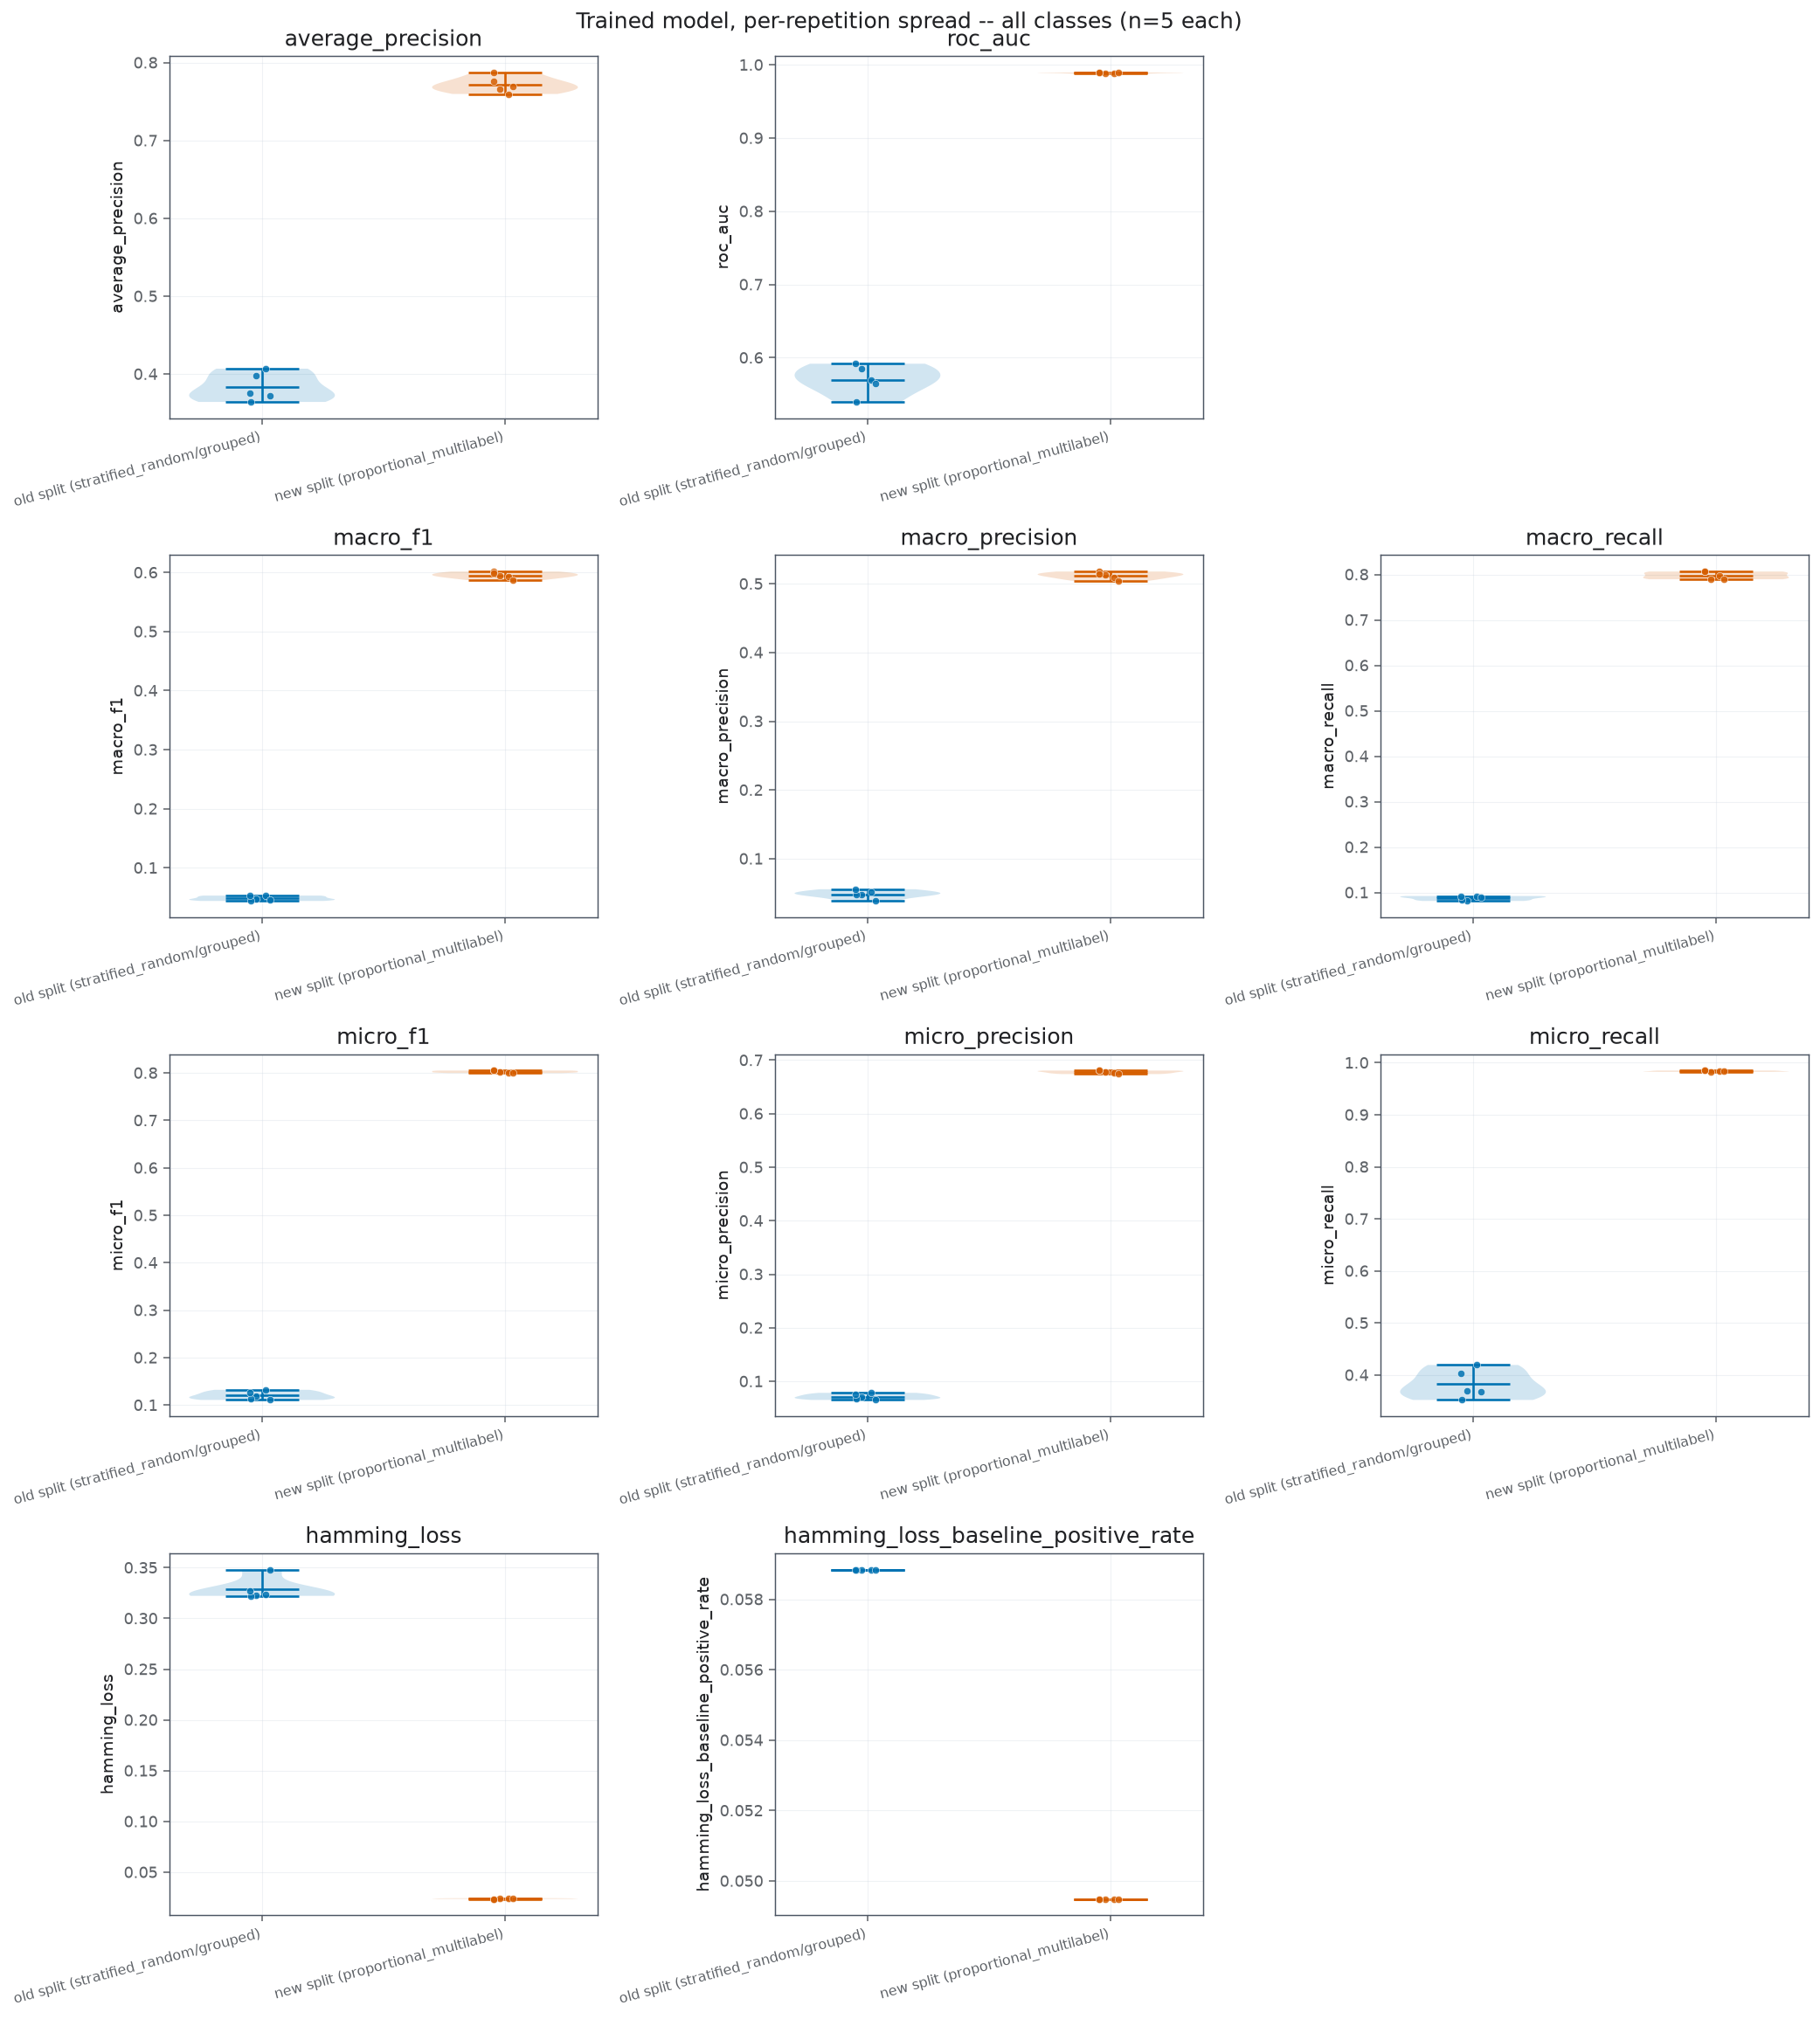

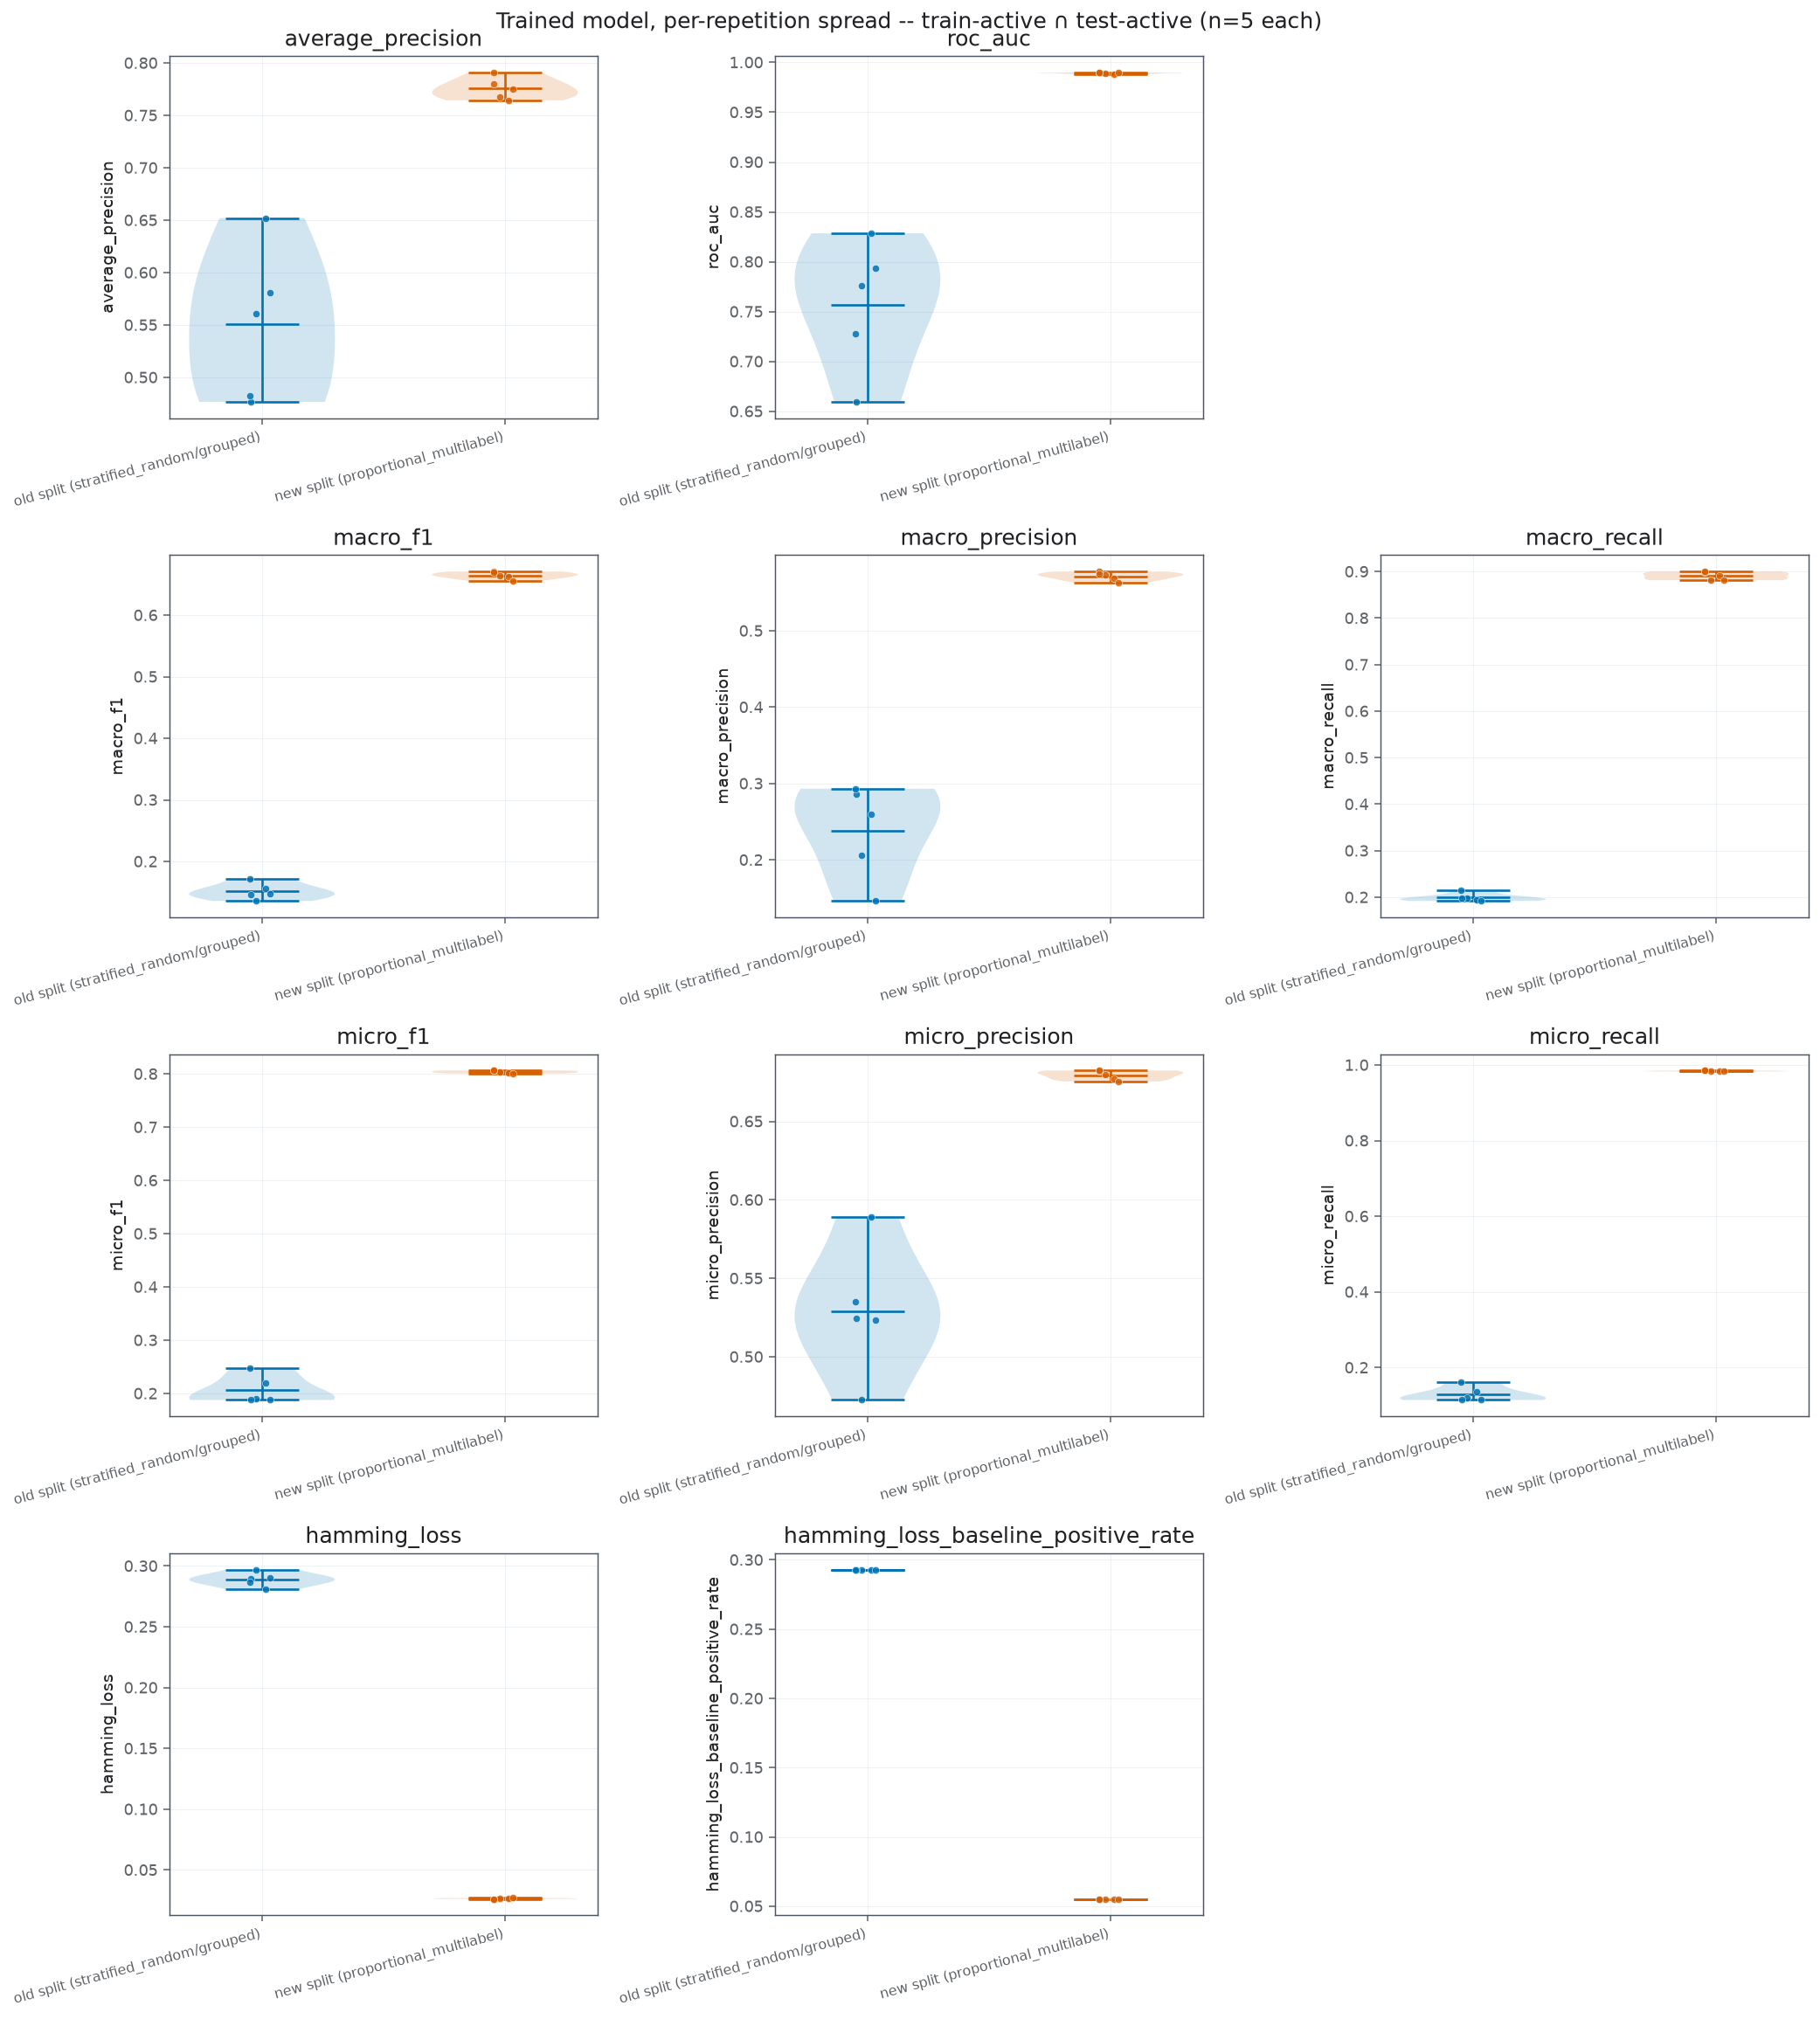

In [8]:
panel_layout = [
    ["average_precision", "roc_auc"],
    ["macro_f1", "macro_precision", "macro_recall"],
    ["micro_f1", "micro_precision", "micro_recall"],
    ["hamming_loss", "hamming_loss_baseline_positive_rate"],
]
campaign_labels = [CAMPAIGNS[key]["label"] for key in CAMPAIGNS]

for scope_name in (ALL_CLASSES_SCOPE, FAIR_SCOPE):
    scoped = trap_frame[(trap_frame["scope"] == scope_name) & (trap_frame["predictor"] == "trained model")]
    figure, axes = plt.subplots(len(panel_layout), 3, figsize=(15.0, 4.2 * len(panel_layout)), dpi=theme.figure_dpi)
    for row, metric_row in enumerate(panel_layout):
        for column in range(3):
            axis = axes[row, column]
            if column >= len(metric_row):
                axis.axis("off")
                continue
            metric_name = metric_row[column]
            for index, (key, label) in enumerate(zip(CAMPAIGNS, campaign_labels)):
                values = scoped.loc[scoped["campaign"] == label, metric_name].to_numpy()
                plot_violin_with_points(values, position=index, ax=axis, width=0.6, color=CAMPAIGN_COLOR[key])
            axis.set_xticks(range(len(campaign_labels)))
            axis.set_xticklabels(campaign_labels, rotation=15, ha="right", fontsize=8)
            axis.set(ylabel=metric_name, title=metric_name)
            axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.suptitle(f"Trained model, per-repetition spread -- {scope_name} (n=5 each)", fontsize=13)
    figure.tight_layout()

## Generalization gap — train vs. validation vs. test (repetition 0)

### Methodology
#### Theoretical
- Same as `part_2`: whether the gap between train/validation/test looks different once
  the split guarantees every class appears in every partition, versus the old
  `dataset_id`-grouped split where `part_2` found validation/test drawing disproportionately
  from classes `train` never saw.

#### Implementation
- `evaluate_materialized` on the already-decoded `train`/`validation`/`test` tensors for
  repetition 0 of each campaign, both class scopes (fair scope recomputed per split,
  matching `part_2`) — no re-decoding.

### Notes

In [9]:
gap_rows = []
for key in CAMPAIGNS:
    materialized = materialized_by_campaign[key]
    train_active = (materialized["train"]["targets"] * materialized["train"]["mask"]).sum(axis=0) > 0
    model = wrappers[key].models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name(key, 0), strict=True)
    model.eval()
    split_results = {
        "train": evaluate_materialized(model, materialized["train"]),
        "validation": evaluate_materialized(model, materialized["validation"]),
        "test": results_by_campaign[key][0],
    }
    for split_name, result in split_results.items():
        split_active = (result["targets"] * result["mask"]).sum(axis=0) > 0
        fair_mask = train_active & split_active
        for scope_name, class_selector in ((ALL_CLASSES_SCOPE, slice(None)), (FAIR_SCOPE, fair_mask)):
            metrics = evaluate_head(
                result["logits"][:, class_selector], result["targets"][:, class_selector],
                "multi_label", result["mask"][:, class_selector], THRESHOLD,
            )
            gap_rows.append({
                "campaign": CAMPAIGNS[key]["label"], "split": split_name, "scope": scope_name,
                "active_classes": int(split_active.sum()), **metrics,
            })

gap_frame = pd.DataFrame(gap_rows)
gap_frame.set_index(["campaign", "split", "scope"])[["active_classes", "average_precision", "roc_auc", "macro_f1"]]

2026-09-05 17:16:06,394 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:16:06,394 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-05 17:16:06,395 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-05 17:16:06,396 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-09-05 17:16:06,398 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-09-05 17:16:21,843 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-05 17:16:21,844 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-05 17:16:21,848 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:16:21,855 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


active_classes  \
campaign                              split      scope                                        
old split (stratified_random/grouped) train      all classes                            194   
                                                 train-active ∩ test-active             194   
                                      validation all classes                            313   
                                                 train-active ∩ test-active             313   
                                      test       all classes                            110   
                                                 train-active ∩ test-active             110   
new split (proportional_multilabel)   train      all classes                            494   
                                                 train-active ∩ test-active             494   
                                      validation all classes                            438   
                                                 train-active ∩ test-active             438   
                                      test       all classes                            461   
                                                 train-active ∩ test-active             461   

                                                                             average_precision  \
campaign                              split      scope                                           
old split (stratified_random/grouped) train      all classes                          0.658512   
                                                 train-active ∩ test-active           0.658512   
                                      validation all classes                          0.218692   
                                                 train-active ∩ test-active           0.343627   
                                      test       all classes                          0.406859   
                                                 train-active ∩ test-active           0.651992   
new split (proportional_multilabel)   train      all classes                          0.700210   
                                                 train-active ∩ test-active           0.700210   
                                      validation all classes                          0.782270   
                                                 train-active ∩ test-active           0.786392   
                                      test       all classes                          0.759733   
                                                 train-active ∩ test-active           0.764337   

                                                                              roc_auc  \
campaign                              split      scope                                  
old split (stratified_random/grouped) train      all classes                 0.978738   
                                                 train-active ∩ test-active  0.978738   
                                      validation all classes                 0.553739   
                                                 train-active ∩ test-active  0.758228   
                                      test       all classes                 0.569178   
                                                 train-active ∩ test-active  0.828513   
new split (proportional_multilabel)   train      all classes                 0.990154   
                                                 train-active ∩ test-active  0.990154   
                                      validation all classes                 0.989130   
                                                 train-active ∩ test-active  0.989365   
                                      test       all classes                 0.987816   
                                                 train-active ∩ test-active  0.988378   

                                                                             macro_f1  
campaign                              

## Closing notes

*(Filled in after execution — see the tables and figure above for the actual values; this
section records interpretation, not methodology.)*